# Trading Risk Dashboard - Multi Asset Analysis

## Objective

This notebook compares the performance and risk characteristics of multiple financial assets.

The analyzed assets are:

- Nasdaq Composite Index
- Brent Crude Oil
- Gold

The objective is to study:

- Performance comparison
- Volatility
- Sharpe Ratio
- Correlation between assets

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

print("Notebook multi-actifs connecté !")

Notebook multi-actifs connecté !


In [2]:
assets = yf.download(
    ["^IXIC", "BZ=F", "GC=F"],
    start="2025-01-01",
    end="2026-01-01"
)

assets.head()

[*********************100%***********************]  3 of 3 completed


Price           Close                                  High               \
Ticker           BZ=F         GC=F         ^IXIC       BZ=F         GC=F   
Date                                                                       
2025-01-02  75.930000  2658.899902  19280.789062  76.540001  2663.100098   
2025-01-03  76.510002  2645.000000  19621.679688  76.739998  2658.699951   
2025-01-06  76.300003  2638.399902  19864.980469  77.500000  2647.000000   
2025-01-07  77.050003  2656.699951  19489.679688  77.269997  2657.500000   
2025-01-08  76.160004  2664.500000  19478.880859  77.889999  2676.899902   

Price                           Low                                  Open  \
Ticker             ^IXIC       BZ=F         GC=F         ^IXIC       BZ=F   
Date                                                                        
2025-01-02  19517.869141  74.730003  2633.000000  19117.589844  74.879997   
2025-01-03  19638.660156  75.529999  2641.800049  19379.570312  75.900002   
2025-01-06  20007.949219  75.940002  2617.300049  19785.000000  76.589996   
2025-01-07  19940.210938  75.919998  2653.000000  19421.019531  76.239998   
2025-01-08  19544.509766  76.029999  2653.500000  19308.539062  77.239998   

Price                                 Volume                      
Ticker             GC=F         ^IXIC   BZ=F  GC=F         ^IXIC  
Date                                                              
2025-01-02  2633.000000  19403.900391  41474  1728  8.737550e+09  
2025-01-03  2658.699951  19395.509766  38822   591  8.214050e+09  
2025-01-06  2645.500000  19851.990234  49229   960  9.586840e+09  
2025-01-07  2653.399902  19938.080078  37188   643  1.337113e+10  
2025-01-08  2655.500000  19469.369141  46650   999  8.851720e+09

In [3]:
prices = assets["Close"]

prices.head()

Ticker,BZ=F,GC=F,^IXIC
Date,,,
2025-01-02,75.930000,2658.899902,19280.789062
2025-01-03,76.510002,2645.000000,19621.679688
2025-01-06,76.300003,2638.399902,19864.980469
2025-01-07,77.050003,2656.699951,19489.679688
2025-01-08,76.160004,2664.500000,19478.880859


In [4]:
returns = prices.pct_change()

returns.head()

C:\Users\ENZO\AppData\Local\Temp\ipykernel_23280\3851176446.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()


Ticker,BZ=F,GC=F,^IXIC
Date,,,
2025-01-02,NaN,NaN,NaN
2025-01-03,0.007639,-0.005228,0.017680
2025-01-06,-0.002745,-0.002495,0.012400
2025-01-07,0.009830,0.006936,-0.018893
2025-01-08,-0.011551,0.002936,-0.000554


In [5]:
cumulative_returns = (1 + returns).cumprod() - 1

cumulative_returns.tail()

Ticker,BZ=F,GC=F,^IXIC
Date,,,
2025-12-24,-0.180298,0.685133,0.224707
2025-12-26,-0.201370,0.703374,0.223658
2025-12-29,-0.184249,0.626650,0.217499
2025-12-30,-0.184512,0.643575,0.214633
2025-12-31,-0.198604,0.626838,0.205448


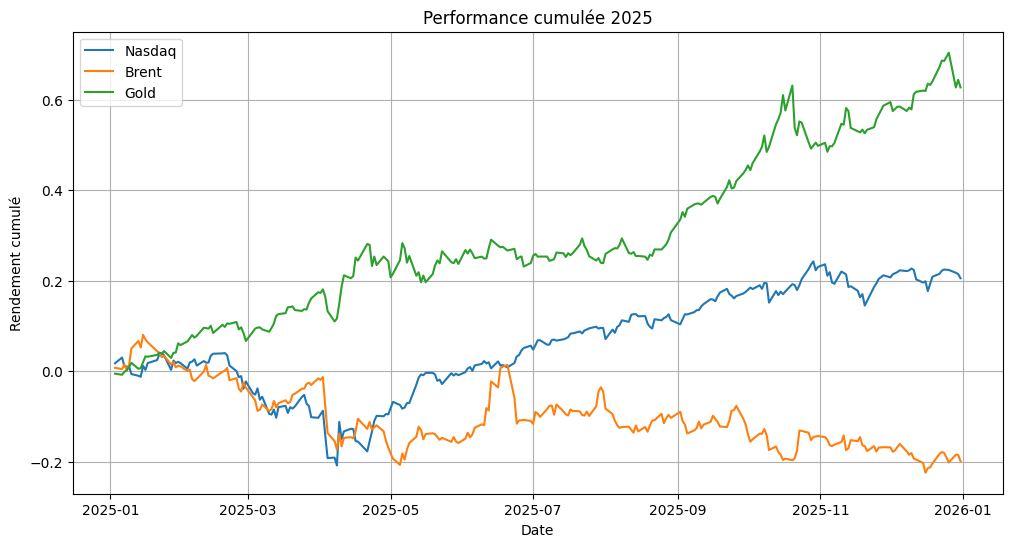

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(cumulative_returns["^IXIC"], label="Nasdaq")
plt.plot(cumulative_returns["BZ=F"], label="Brent")
plt.plot(cumulative_returns["GC=F"], label="Gold")

plt.title("Performance cumulée 2025")
plt.xlabel("Date")
plt.ylabel("Rendement cumulé")

plt.legend()
plt.grid(True)

plt.show()

En 2025, l'or a affiché une performance supérieure au Nasdaq et au Brent, illustrant son rôle potentiel d'actif défensif dans un environnement marqué par l'incertitude macroéconomique. Le Brent a sous-performé, probablement sous l'effet des anticipations concernant la demande énergétique et la croissance mondiale. Toutefois, la performance seule ne permet pas de conclure sur la qualité d'un actif : une analyse du risque et des corrélations est nécessaire.

In [7]:
daily_volatility = returns.std()

print(daily_volatility)

Ticker
BZ=F     0.018095
GC=F     0.012906
^IXIC    0.015321
dtype: float64


In [8]:
annual_volatility = daily_volatility * np.sqrt(252)

print(annual_volatility)

Ticker
BZ=F     0.287247
GC=F     0.204878
^IXIC    0.243218
dtype: float64


In [9]:
average_returns = returns.mean()

sharpe_ratios = (
    average_returns / daily_volatility
) * np.sqrt(252)

print(sharpe_ratios)

Ticker
BZ=F    -0.629827
GC=F     2.489461
^IXIC    0.891326
dtype: float64


In [11]:
correlation_matrix = returns.corr()

print(correlation_matrix)

Ticker      BZ=F      GC=F     ^IXIC
Ticker                              
BZ=F    1.000000  0.089233  0.253774
GC=F    0.089233  1.000000  0.004532
^IXIC   0.253774  0.004532  1.000000


In [12]:
import seaborn as sns

print(sns.__version__)

0.13.2


In [13]:
import sys

print(sys.executable)

c:\Users\ENZO\Documents\GitHub\Trading-Risk-Dashboard\.venv\Scripts\python.exe


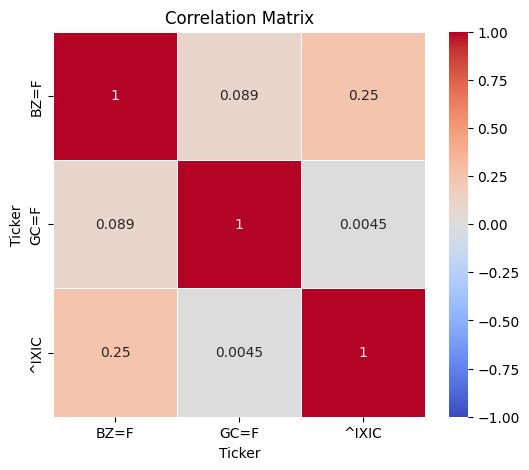

In [14]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

# Conclusion

This multi asset analysis highlights the different risk and performance profiles of financial markets.

Key observations:

- Gold showed the strongest risk-adjusted performance during the analyzed period.
- The Nasdaq generated positive returns but with higher volatility.
- Brent displayed weaker performance compared to the other assets.
- Correlation analysis showed relatively limited relationships between assets, suggesting potential diversification benefits.

This analysis demonstrates how quantitative indicators can be used to compare financial assets and evaluate their risk characteristics.

Further research could investigate more advanced risk management strategies such as hedging and portfolio optimization.